# Micro-CT Segmentation Pipeline

Единый ноутбук: подготовка данных → обучение 3D-сегментации → валидация качества маски.

Фокус проекта — **качественная сегментация пор на разных породах и размерах кубов**.
Контур проницаемости (PoreSpy/OpenPNM/GNN) из пайплайна удалён: без независимого
ground truth (LBM/эксперимент) обучать предсказание k некорректно.

Лосс сегментации = воксельная точность + топология:

| Член | Что ловит |
|---|---|
| BCE + Dice | повоксельная точность |
| **clDice** | разрывы/ложные перемычки скелета пор (связность!) |
| aux (porosity/percolation) | глобальные свойства маски |
| topo-head (PH) | регуляризация представлений |

Валидация — не только Dice: clDice, числа Бетти (b0/b1/b2), связная пористость,
перколяция по осям. Именно эти метрики чувствуют ошибки, которые рушат
производные свойства породы.


---
## 0. Setup & Environment Check

Эту ячейку нужно выполнить **всегда первой** — она настраивает пути и проверяет зависимости.

In [1]:
from pathlib import Path
import sys
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

ROOT = Path.cwd()
for candidate in (ROOT, *ROOT.parents):
    if (candidate / "src" / "utils").is_dir():
        ROOT = candidate
        break
else:
    raise RuntimeError("Project root with src/utils was not found")

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print("ROOT:", ROOT)

ROOT: f:\PycharmProjects\micro_ct


In [2]:
import torch

from utils import check_required_dependencies

status = check_required_dependencies()
print(status)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

{'numpy': True, 'pandas': True, 'scipy': True, 'skimage': True, 'torch': True, 'gudhi': True}
torch: 2.10.0+cu126
cuda available: True
device: cuda


---
## 1. Prepare Data

Сканирует rock-папки в `data/` и записывает индексные CSV-файлы в `datasets/`.
**Запускать один раз** при добавлении новой породы или изменении состава данных.

Если `datasets/` уже заполнены — **пропусти эту секцию**.

In [3]:
import pandas as pd

from utils import (
    DEFAULT_CUBE_SIZES,
    discover_rock_volumes,
    write_patch_indices,
)

In [4]:
DATA_ROOT = ROOT / "data"
INDEX_ROOT = ROOT / "datasets"
CUBE_SIZES = list(DEFAULT_CUBE_SIZES)
SHAPE = (1000, 1000, 1000)
ROCKS = None  # или ["Berea", "BanderaBrown"]
VAL_FRACTION = 0.2
SEED = 42
COMPUTE_AUX_TARGETS = True
PORE_VALUE = 0
STRIDE_BY_SIZE = {64: 64, 128: 128, 192: 192}
NUM_WORKERS = 16 # параллельная обработка перколяции (0 = последовательно)
FORCE = False  # True = перезаписать существующие CSV

print("cube sizes:", CUBE_SIZES)


cube sizes: [64, 128, 192]


In [5]:
specs = discover_rock_volumes(ROOT, data_root=DATA_ROOT, index_root=INDEX_ROOT, rocks=ROCKS, shape=SHAPE)
pd.DataFrame([
    {
        "rock": spec.name,
        "data_dir": str(spec.data_dir),
        "index_dir": str(INDEX_ROOT / spec.name),
        "gray": str(spec.gray_path),
        "binary": str(spec.binary_path),
        "shape": spec.shape,
    }
    for spec in specs
])

,rock,data_dir,index_dir,gray,binary,shape
0,BanderaBrown,f:\PycharmProjects\micro_ct\data\BanderaBrown,f:\PycharmProjects\micro_ct\datasets\BanderaBrown,f:\PycharmProjects\micro_ct\data\BanderaBrown\...,f:\PycharmProjects\micro_ct\data\BanderaBrown\...,"(1000, 1000, 1000)"
1,BanderaGray,f:\PycharmProjects\micro_ct\data\BanderaGray,f:\PycharmProjects\micro_ct\datasets\BanderaGray,f:\PycharmProjects\micro_ct\data\BanderaGray\B...,f:\PycharmProjects\micro_ct\data\BanderaGray\B...,"(1000, 1000, 1000)"
2,Berea,f:\PycharmProjects\micro_ct\data\Berea,f:\PycharmProjects\micro_ct\datasets\Berea,f:\PycharmProjects\micro_ct\data\Berea\Berea_2...,f:\PycharmProjects\micro_ct\data\Berea\Berea_2...,"(1000, 1000, 1000)"


In [6]:
summary = write_patch_indices(
    ROOT,
    data_root=DATA_ROOT,
    index_root=INDEX_ROOT,
    rocks=ROCKS,
    cube_sizes=CUBE_SIZES,
    shape=SHAPE,
    stride_by_size=STRIDE_BY_SIZE,
    val_fraction=VAL_FRACTION,
    seed=SEED,
    compute_aux_targets=COMPUTE_AUX_TARGETS,
    pore_value=PORE_VALUE,
    num_workers=NUM_WORKERS,  
    force=FORCE,  
)

summary.groupby(["rock", "cube_size", "split"]).size().rename("samples").reset_index()


,rock,cube_size,split,samples
0,BanderaBrown,64,train,3072
1,BanderaBrown,64,val,768
2,BanderaBrown,128,train,384
3,BanderaBrown,128,val,64
4,BanderaBrown,192,train,144
5,BanderaBrown,192,val,36
6,BanderaGray,64,train,3072
7,BanderaGray,64,val,768
8,BanderaGray,128,train,384
9,BanderaGray,128,val,64


---
## 2. Train Segmentation Model

Обучает TopologyAdaptiveRoutedUNet3D на raw-кубах → бинарные маски пор.
Сохраняет лучший чекпоинт в `models/segmentation_best.pth`.
При `TRAIN_MODE = "quick"` — обучение с ограничением по батчам (для итераций).
При `TRAIN_MODE = "full"` — полная эпоха.

In [7]:
import importlib
from torch.utils.data import DataLoader
from tqdm import tqdm

import utils.common as common_module
import utils.data as data_module
import utils.adaptive_routing as adaptive_module
import utils.losses as losses_module

common_module = importlib.reload(common_module)
data_module = importlib.reload(data_module)
adaptive_module = importlib.reload(adaptive_module)
losses_module = importlib.reload(losses_module)

BCEDiceLoss = losses_module.BCEDiceLoss
SoftClDiceLoss = losses_module.SoftClDiceLoss
DEFAULT_CUBE_SIZES = data_module.DEFAULT_CUBE_SIZES
BereaPatchDataset = data_module.BereaPatchDataset
CubeSizeBatchSampler = data_module.CubeSizeBatchSampler
TopologyAdaptiveRoutedUNet3D = adaptive_module.TopologyAdaptiveRoutedUNet3D
auxiliary_physics_loss = losses_module.auxiliary_physics_loss
dice_score_from_logits = losses_module.dice_score_from_logits
topology_prediction_loss = losses_module.topology_prediction_loss
from utils.training import EarlyStopping, MetricTracker
from utils.topology import TOPOLOGY_FEATURE_DIM

In [8]:
TRAIN_MODE = "quick"  # quick | full
CUBE_SIZES = list(DEFAULT_CUBE_SIZES)
BATCH_SIZE_BY_CUBE_SIZE = {64: 2, 128: 1, 192: 1}
EPOCHS = 10
LR = 1e-4
AUX_WEIGHT = 0.05
TOPOLOGY_WEIGHT = 0.01
CLDICE_WEIGHT = 0.3        # связность скелета; 0 — отключить
CLDICE_ITERS = 10          # >= макс. радиуса пор в вокселях
PATIENCE = 3
MIN_DELTA = 1e-4
BASE_CHANNELS = 16
CTX_DIM = 64
PH_DIM = TOPOLOGY_FEATURE_DIM
SAMPLES_PER_GROUP = 8 if TRAIN_MODE == "quick" else None
MAX_TRAIN_BATCHES = 64 if TRAIN_MODE == "quick" else None
MAX_VAL_BATCHES = 16 if TRAIN_MODE == "quick" else None
SIZE_SAMPLING_WEIGHTS = {64: 0.50, 128: 0.35, 192: 0.15}
NUM_WORKERS = 0
PIN_MEMORY = device == "cuda"
USE_AMP = device == "cuda"
SAVE_CHECKPOINT = True
CHECKPOINT_PATH = ROOT / "models" / "segmentation_best.pth"

In [9]:
MODEL_DIR = ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

train_ds = BereaPatchDataset(
    ROOT,
    split="train",
    cube_size=CUBE_SIZES,
    use_raw_gray=False,
    balance=True,
    samples_per_group=SAMPLES_PER_GROUP,
    size_sampling_weights=SIZE_SAMPLING_WEIGHTS,
    return_topology=True,
)
val_ds = BereaPatchDataset(
    ROOT,
    split="val",
    cube_size=CUBE_SIZES,
    use_raw_gray=False,
    noise_types=["none"],
    balance=False,
    samples_per_group=SAMPLES_PER_GROUP,
    return_topology=True,
)

train_sampler = CubeSizeBatchSampler(train_ds, BATCH_SIZE_BY_CUBE_SIZE, shuffle=True, seed=42)
val_sampler = CubeSizeBatchSampler(val_ds, BATCH_SIZE_BY_CUBE_SIZE, shuffle=False, seed=42)
train_loader = DataLoader(train_ds, batch_sampler=train_sampler, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_ds, batch_sampler=val_sampler, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
print("mode:", TRAIN_MODE, "cube sizes:", CUBE_SIZES)
print("train:", len(train_ds), "val:", len(val_ds), "batches:", len(train_loader), len(val_loader))

mode: quick cube sizes: [64, 128, 192]
train: 72 val: 72 batches: 54 60


In [10]:
model = TopologyAdaptiveRoutedUNet3D(
    in_channels=1,
    out_channels=1,
    base_channels=BASE_CHANNELS,
    ctx_dim=CTX_DIM,
    ph_dim=PH_DIM,
    topology_dim=PH_DIM,
).to(device)
criterion = BCEDiceLoss()
cldice_criterion = SoftClDiceLoss(num_iters=CLDICE_ITERS)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
print("parameters:", sum(p.numel() for p in model.parameters()))

c:\Users\F\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\module.py:1367: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:39.)
  return t.to(


parameters: 1445714


In [11]:
early_stopping = EarlyStopping(patience=PATIENCE, min_delta=MIN_DELTA, mode="min")
history = []
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_stats = MetricTracker()
    train_bar = tqdm(train_loader, desc=f"train {epoch}/{EPOCHS}", leave=False)
    for batch_idx, batch in enumerate(train_bar):
        if MAX_TRAIN_BATCHES is not None and batch_idx >= MAX_TRAIN_BATCHES:
            break
        x = batch["x"].to(device)
        y = batch["y"].to(device)
        ph_features = batch.get("ph_features")
        topology_target = batch.get("topology_target")
        if ph_features is not None:
            ph_features = ph_features.to(device)
        if topology_target is not None:
            topology_target = topology_target.to(device)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type="cuda" if USE_AMP else "cpu", enabled=USE_AMP):
            out = model(x, ph_features=ph_features, return_dict=True)
            logits = out["logits"]
            seg_loss, bce_loss, dice_loss = criterion(logits, y)
            aux_loss, aux_parts = auxiliary_physics_loss(
                out, y,
                porosity_target=batch["porosity"].to(device),
                percolation_target=batch["percolates"].to(device),
                porosity_weight=AUX_WEIGHT,
                percolation_weight=AUX_WEIGHT,
            )
            topo_loss, topo_parts = topology_prediction_loss(
                out, topology_target, topology_weight=TOPOLOGY_WEIGHT
            )
            cldice_loss = (
                cldice_criterion(logits, y) if CLDICE_WEIGHT > 0 else logits.new_tensor(0.0)
            )
            loss = seg_loss + CLDICE_WEIGHT * cldice_loss + aux_loss + topo_loss
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = x.size(0)
        with torch.no_grad():
            dice = dice_score_from_logits(logits, y)
        train_stats.update("loss", float(loss.detach().cpu()), batch_size)
        train_stats.update("seg_loss", float(seg_loss.detach().cpu()), batch_size)
        train_stats.update("cldice", float(cldice_loss.detach().cpu()), batch_size)
        train_stats.update("dice", float(dice.detach().cpu()), batch_size)
        train_bar.set_postfix(train_stats.postfix("loss", "dice"))

    model.eval()
    val_stats = MetricTracker()
    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f"val {epoch}/{EPOCHS}", leave=False)
        for batch_idx, batch in enumerate(val_bar):
            if MAX_VAL_BATCHES is not None and batch_idx >= MAX_VAL_BATCHES:
                break
            x = batch["x"].to(device)
            y = batch["y"].to(device)
            ph_features = batch.get("ph_features")
            topology_target = batch.get("topology_target")
            if ph_features is not None:
                ph_features = ph_features.to(device)
            if topology_target is not None:
                topology_target = topology_target.to(device)

            with torch.amp.autocast(device_type="cuda" if USE_AMP else "cpu", enabled=USE_AMP):
                out = model(x, ph_features=ph_features, return_dict=True)
                logits = out["logits"]
                seg_loss, bce_loss, dice_loss = criterion(logits, y)
                aux_loss, aux_parts = auxiliary_physics_loss(
                    out, y,
                    porosity_target=batch["porosity"].to(device),
                    percolation_target=batch["percolates"].to(device),
                    porosity_weight=AUX_WEIGHT,
                    percolation_weight=AUX_WEIGHT,
                )
                topo_loss, topo_parts = topology_prediction_loss(
                    out, topology_target, topology_weight=TOPOLOGY_WEIGHT
                )
                cldice_loss = (
                    cldice_criterion(logits, y) if CLDICE_WEIGHT > 0 else logits.new_tensor(0.0)
                )
                loss = seg_loss + CLDICE_WEIGHT * cldice_loss + aux_loss + topo_loss
            dice = dice_score_from_logits(logits, y)

            batch_size = x.size(0)
            val_stats.update("loss", float(loss.detach().cpu()), batch_size)
            val_stats.update("dice", float(dice.detach().cpu()), batch_size)
            val_stats.update("cldice", float(cldice_loss.detach().cpu()), batch_size)
            val_bar.set_postfix(val_stats.postfix("loss", "dice"))

    train_metrics = train_stats.as_dict()
    val_metrics = val_stats.as_dict()
    history.append({"epoch": epoch,
                    "train_loss": train_metrics["loss"], "train_dice": train_metrics["dice"],
                    "train_cldice": train_metrics.get("cldice", 0.0),
                    "val_loss": val_metrics["loss"], "val_dice": val_metrics["dice"],
                    "val_cldice": val_metrics.get("cldice", 0.0)})
    print(f"epoch={epoch} train_loss={train_metrics['loss']:.4f} train_dice={train_metrics['dice']:.4f} "
          f"val_loss={val_metrics['loss']:.4f} val_dice={val_metrics['dice']:.4f} "
          f"val_cldice={val_metrics.get('cldice', 0.0):.4f}")

    improved = early_stopping.step(val_metrics["loss"], epoch=epoch)
    if improved and SAVE_CHECKPOINT:
        torch.save({
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "val_loss": val_metrics["loss"],
            "val_dice": val_metrics["dice"],
            "history": history,
            "base_channels": BASE_CHANNELS,
            "ctx_dim": CTX_DIM,
            "ph_dim": PH_DIM,
            "topology_dim": PH_DIM,
        }, CHECKPOINT_PATH)
        print("saved:", CHECKPOINT_PATH)
    if early_stopping.should_stop:
        print(f"early stop at epoch={epoch}; best val_loss={early_stopping.best:.4f}")
        break

epoch=1 train_loss=0.5611 train_dice=0.6671 val_loss=0.3116 val_dice=0.8123 val_cldice=0.1891
saved: f:\PycharmProjects\micro_ct\models\segmentation_best.pth


epoch=2 train_loss=0.2274 train_dice=0.8658 val_loss=0.1983 val_dice=0.8800 val_cldice=0.1136
saved: f:\PycharmProjects\micro_ct\models\segmentation_best.pth


epoch=3 train_loss=0.1526 train_dice=0.9067 val_loss=0.1891 val_dice=0.8890 val_cldice=0.0963
saved: f:\PycharmProjects\micro_ct\models\segmentation_best.pth


KeyboardInterrupt: 

In [12]:
import sys, gc, torch
sys.last_traceback = sys.last_value = sys.last_type = None
gc.collect()
torch.cuda.empty_cache()
print(f"{torch.cuda.memory_allocated()/2**30:.2f} GiB allocated")

0.53 GiB allocated


---
## 3. Кривые обучения

Быстрая проверка после тренировки: сходимость, переобучение, вклад clDice.
Если переменной `history` нет в памяти (kernel перезапущен) — история
подтягивается из чекпоинта.


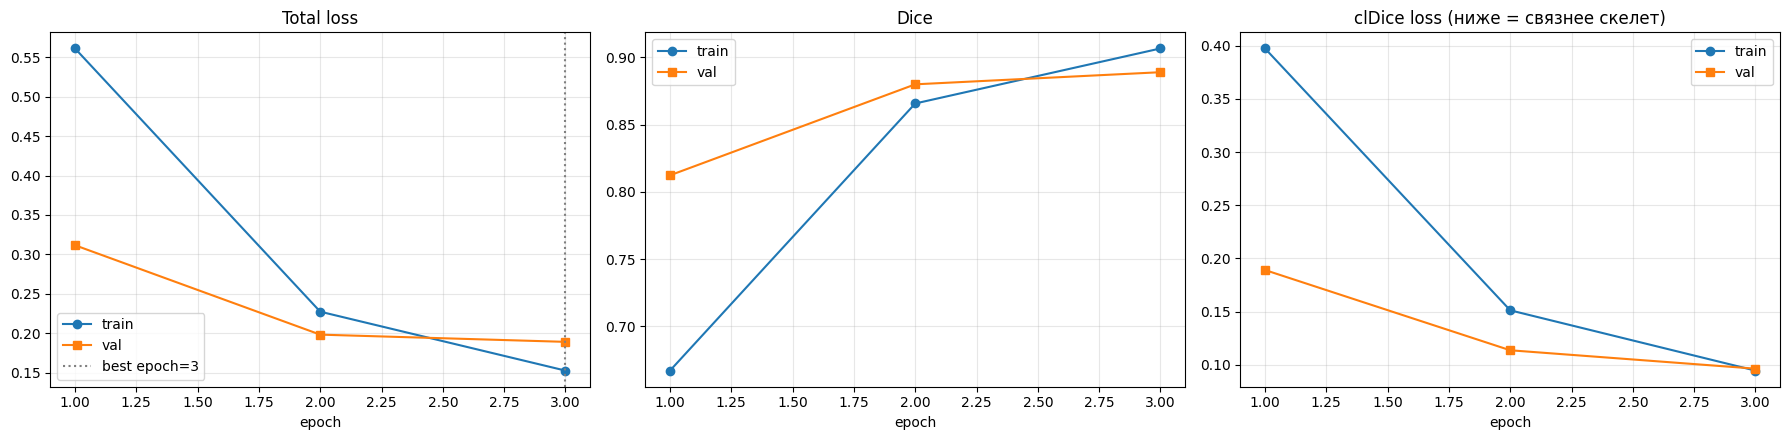

,train_loss,train_dice,train_cldice,val_loss,val_dice,val_cldice
epoch,,,,,,
1,0.5611,0.6671,0.3975,0.3116,0.8123,0.1891
2,0.2274,0.8658,0.1512,0.1983,0.8800,0.1136
3,0.1526,0.9067,0.0945,0.1891,0.8890,0.0963


In [13]:
import matplotlib.pyplot as plt
import pandas as pd

if "history" not in globals() or not history:
    ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
    history = ckpt["history"]
    print(f"history загружена из чекпоинта: {CHECKPOINT_PATH}")

hist_df = pd.DataFrame(history).set_index("epoch")

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].plot(hist_df.index, hist_df["train_loss"], "o-", label="train")
axes[0].plot(hist_df.index, hist_df["val_loss"], "s-", label="val")
best_epoch = hist_df["val_loss"].idxmin()
axes[0].axvline(best_epoch, color="gray", linestyle=":", label=f"best epoch={best_epoch}")
axes[0].set_title("Total loss"); axes[0].set_xlabel("epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist_df.index, hist_df["train_dice"], "o-", label="train")
axes[1].plot(hist_df.index, hist_df["val_dice"], "s-", label="val")
axes[1].set_title("Dice"); axes[1].set_xlabel("epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

if "val_cldice" in hist_df.columns:
    axes[2].plot(hist_df.index, hist_df["train_cldice"], "o-", label="train")
    axes[2].plot(hist_df.index, hist_df["val_cldice"], "s-", label="val")
    axes[2].set_title("clDice loss (ниже = связнее скелет)")
    axes[2].set_xlabel("epoch"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

display(hist_df.round(4))


---
## 4. Validate Segmentation

Полная оценка чекпоинта на val: воксельные метрики (Dice, BCE, error rate)
**плюс топологические** — clDice, числа Бетти, связная пористость, перколяция.

Betti/перколяция считаются на CPU по одному кубу: для кубов >128³ это заметно
дольше, поэтому есть переключатель `COMPUTE_TOPO_METRICS` и ограничение
`TOPO_METRICS_MAX_CUBE`.


In [14]:
import time
import warnings
from itertools import islice

import numpy as np
import pandas as pd

from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

import matplotlib
matplotlib.use('inline')
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

In [15]:
CHECKPOINT_PATH = ROOT / "models" / "segmentation_best.pth"  # или свой чекпоинт
CUBE_SIZES = [64, 128]
BATCH_SIZE_BY_CUBE_SIZE = {64: 16, 128: 2, 192: 1}
VAL_SAMPLES_PER_GROUP = 16
NUM_WORKERS = 0
PIN_MEMORY = device == "cuda"
MAX_VAL_BATCHES = 8
USE_RAM_CACHE = True
COMPUTE_TOPO_METRICS = True   # clDice/Betti/перколяция (CPU, медленнее)
TOPO_METRICS_MAX_CUBE = 128   # для кубов больше — только воксельные метрики

In [16]:
import utils.data as data_module
import utils.adaptive_routing as adaptive_module
import utils.losses as losses_module
import importlib

data_module = importlib.reload(data_module)
adaptive_module = importlib.reload(adaptive_module)
losses_module = importlib.reload(losses_module)

BereaPatchDataset = data_module.BereaPatchDataset
CubeSizeBatchSampler = data_module.CubeSizeBatchSampler
TopologyAdaptiveRoutedUNet3D = adaptive_module.TopologyAdaptiveRoutedUNet3D
dice_score_from_logits = losses_module.dice_score_from_logits

import utils.seg_metrics as seg_metrics_module
seg_metrics_module = importlib.reload(seg_metrics_module)
segmentation_quality_report = seg_metrics_module.segmentation_quality_report

In [17]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
base_channels = int(checkpoint.get("base_channels", 16))
ctx_dim = int(checkpoint.get("ctx_dim", 64))
ph_dim = int(checkpoint.get("ph_dim", 6))
print(f"Loaded: base_channels={base_channels}, ctx_dim={ctx_dim}, ph_dim={ph_dim}")
print(f"Best val_loss={checkpoint['val_loss']:.4f}, val_dice={checkpoint['val_dice']:.4f} at epoch={checkpoint['epoch']}")

model = TopologyAdaptiveRoutedUNet3D(
    in_channels=1, out_channels=1,
    base_channels=base_channels, ctx_dim=ctx_dim,
    ph_dim=ph_dim, topology_dim=ph_dim,
).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Loaded: base_channels=16, ctx_dim=64, ph_dim=6
Best val_loss=0.1891, val_dice=0.8890 at epoch=3
Parameters: 1,445,714


In [18]:
val_ds = BereaPatchDataset(
    ROOT, split="val", cube_size=CUBE_SIZES, use_raw_gray=False,
    noise_types=["none"], balance=False,
    samples_per_group=VAL_SAMPLES_PER_GROUP,
    return_aux_targets=False, return_topology=True,
)

class CachedPatchDataset:
    def __init__(self, dataset):
        import time
        self.samples = []
        start = time.perf_counter()
        for idx in tqdm(range(len(dataset)), desc="Caching val cubes", leave=False):
            sample = dataset[idx]
            self.samples.append({k: v.contiguous() if isinstance(v, torch.Tensor) else v for k, v in sample.items()})
        self.df = dataset.df.iloc[dataset.sample_index].reset_index(drop=True)
        self.sample_index = np.arange(len(self.samples))
        self.cube_sizes = dataset.cube_sizes
        elapsed = time.perf_counter() - start
        print(f"Cached {len(self.samples)} cubes in RAM in {elapsed:.1f}s")
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx): return self.samples[int(idx)]

if USE_RAM_CACHE:
    val_ds = CachedPatchDataset(val_ds)

val_sampler = CubeSizeBatchSampler(val_ds, BATCH_SIZE_BY_CUBE_SIZE, shuffle=False)
val_loader = DataLoader(val_ds, batch_sampler=val_sampler, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
print(f"Val dataset: {len(val_ds)} samples, {len(val_loader)} batches")
display(val_ds.df.groupby(["rock", "cube_size"]).size().rename("count").reset_index())

Caching val cubes:   0%|          | 0/96 [00:00<?, ?it/s]

Cached 96 cubes in RAM in 103.9s
Val dataset: 96 samples, 27 batches


,rock,cube_size,count
0,BanderaBrown,64,16
1,BanderaBrown,128,16
2,BanderaGray,64,16
3,BanderaGray,128,16
4,Berea,64,16
5,Berea,128,16


In [19]:
results = []
bce_loss_fn = torch.nn.BCEWithLogitsLoss(reduction="none")

total_batches = len(val_loader) if MAX_VAL_BATCHES is None else min(len(val_loader), MAX_VAL_BATCHES)
val_iter = val_loader if MAX_VAL_BATCHES is None else islice(val_loader, MAX_VAL_BATCHES)
val_bar = tqdm(val_iter, total=total_batches, desc="Validation")

with torch.inference_mode():
    for batch in val_bar:
        x = batch["x"].to(device, non_blocking=PIN_MEMORY)
        y = batch["y"].to(device, non_blocking=PIN_MEMORY)
        ph_features = batch.get("ph_features")
        if ph_features is not None:
            ph_features = ph_features.to(device, non_blocking=PIN_MEMORY)

        out = model(x, ph_features=ph_features, return_dict=True)
        logits = out["logits"]
        prob = torch.sigmoid(logits)
        pred_mask = (prob >= 0.5).float()

        flat_pred = pred_mask.flatten(1)
        flat_y = y.flatten(1)
        intersection = (flat_pred * flat_y).sum(dim=1)
        denom = flat_pred.sum(dim=1) + flat_y.sum(dim=1)
        dice_values = ((2.0 * intersection + 1e-6) / (denom + 1e-6)).detach().cpu().tolist()
        bce_values = bce_loss_fn(logits, y).flatten(1).mean(dim=1).detach().cpu().tolist()
        error_values = (pred_mask != y).float().flatten(1).mean(dim=1).detach().cpu().tolist()

        rocks = list(batch["rock"]) if isinstance(batch["rock"], (list, tuple)) else [str(batch["rock"])] * x.size(0)
        cube_sizes = batch["cube_size"].detach().cpu().tolist()
        porosities = y.flatten(1).mean(dim=1).detach().cpu().tolist()

        for i in range(x.size(0)):
            row = {
                "rock": rocks[i], "cube_size": int(cube_sizes[i]),
                "porosity": float(porosities[i]),
                "dice": float(dice_values[i]),
                "bce_loss": float(bce_values[i]),
                "error_rate": float(error_values[i]),
            }
            if COMPUTE_TOPO_METRICS and int(cube_sizes[i]) <= TOPO_METRICS_MAX_CUBE:
                pred_np = pred_mask[i, 0].cpu().numpy().astype(bool)
                gt_np = y[i, 0].cpu().numpy().astype(bool)
                row.update(segmentation_quality_report(pred_np, gt_np))
            results.append(row)

df = pd.DataFrame(results)
print(f"\nProcessed {len(df)} cubes")
print(f"Mean Dice: {df['dice'].mean():.4f} ± {df['dice'].std():.4f}")
print(f"Mean error: {df['error_rate'].mean():.4f} ± {df['error_rate'].std():.4f}")
if "cl_dice" in df.columns:
    topo_df = df.dropna(subset=["cl_dice"])
    print(f"Mean clDice: {topo_df['cl_dice'].mean():.4f} ± {topo_df['cl_dice'].std():.4f}  (n={len(topo_df)})")
    print(f"Mean |Δb0|: {topo_df['betti0_abs_err'].mean():.1f}   Mean |Δb1|: {topo_df['betti1_abs_err'].mean():.1f}")
    print(f"Percolation match: {topo_df['percolation_match'].mean():.3f}")

Validation:   0%|          | 0/8 [00:00<?, ?it/s]


Processed 58 cubes
Mean Dice: 0.8924 ± 0.0556
Mean error: 0.0440 ± 0.0360
Mean clDice: 0.9192 ± 0.0580  (n=58)
Mean |Δb0|: 10.0   Mean |Δb1|: 11.7
Percolation match: 0.902


In [20]:
print("DICE BY ROCK")
display(df.groupby("rock")["dice"].agg(["mean", "std", "min", "max", "count"]).round(4))
print("\nDICE BY CUBE SIZE")
display(df.groupby("cube_size")["dice"].agg(["mean", "std", "min", "max", "count"]).round(4))
print("\nDICE BY ROCK × CUBE SIZE")
display(df.groupby(["rock", "cube_size"])["dice"].agg(["mean", "std", "min", "max", "count"]).round(4))

if "cl_dice" in df.columns:
    topo_cols = ["cl_dice", "betti0_abs_err", "betti1_abs_err",
                 "connected_porosity_abs_err", "percolation_match"]
    print("\nTOPOLOGY METRICS BY ROCK")
    display(df.dropna(subset=["cl_dice"]).groupby("rock")[topo_cols].mean().round(4))
    print("\nTOPOLOGY METRICS BY CUBE SIZE")
    display(df.dropna(subset=["cl_dice"]).groupby("cube_size")[topo_cols].mean().round(4))

DICE BY ROCK


,mean,std,min,max,count
rock,,,,,
BanderaBrown,0.9200,0.0218,0.8741,0.9476,26
BanderaGray,0.8512,0.0553,0.7259,0.9100,16
Berea,0.8888,0.0690,0.7177,0.9580,16



DICE BY CUBE SIZE


,mean,std,min,max,count
cube_size,,,,,
64,0.8845,0.0576,0.7177,0.9580,48
128,0.9303,0.0174,0.9031,0.9476,10



DICE BY ROCK × CUBE SIZE


mean     std     min     max  count
rock         cube_size                                       
BanderaBrown 64         0.9135  0.0222  0.8741  0.9405     16
             128        0.9303  0.0174  0.9031  0.9476     10
BanderaGray  64         0.8512  0.0553  0.7259  0.9100     16
Berea        64         0.8888  0.0690  0.7177  0.9580     16


TOPOLOGY METRICS BY ROCK


,cl_dice,betti0_abs_err,betti1_abs_err,connected_porosity_abs_err,percolation_match
rock,,,,,
BanderaBrown,0.9509,12.5769,17.5385,0.0258,0.9615
BanderaGray,0.8832,10.1250,10.8125,0.0589,0.7292
Berea,0.9038,5.6250,3.2500,0.0530,0.9792



TOPOLOGY METRICS BY CUBE SIZE


,cl_dice,betti0_abs_err,betti1_abs_err,connected_porosity_abs_err,percolation_match
cube_size,,,,,
64,0.9099,6.8333,6.7292,0.0462,0.8819
128,0.9637,25.1000,35.8000,0.0245,1.0000


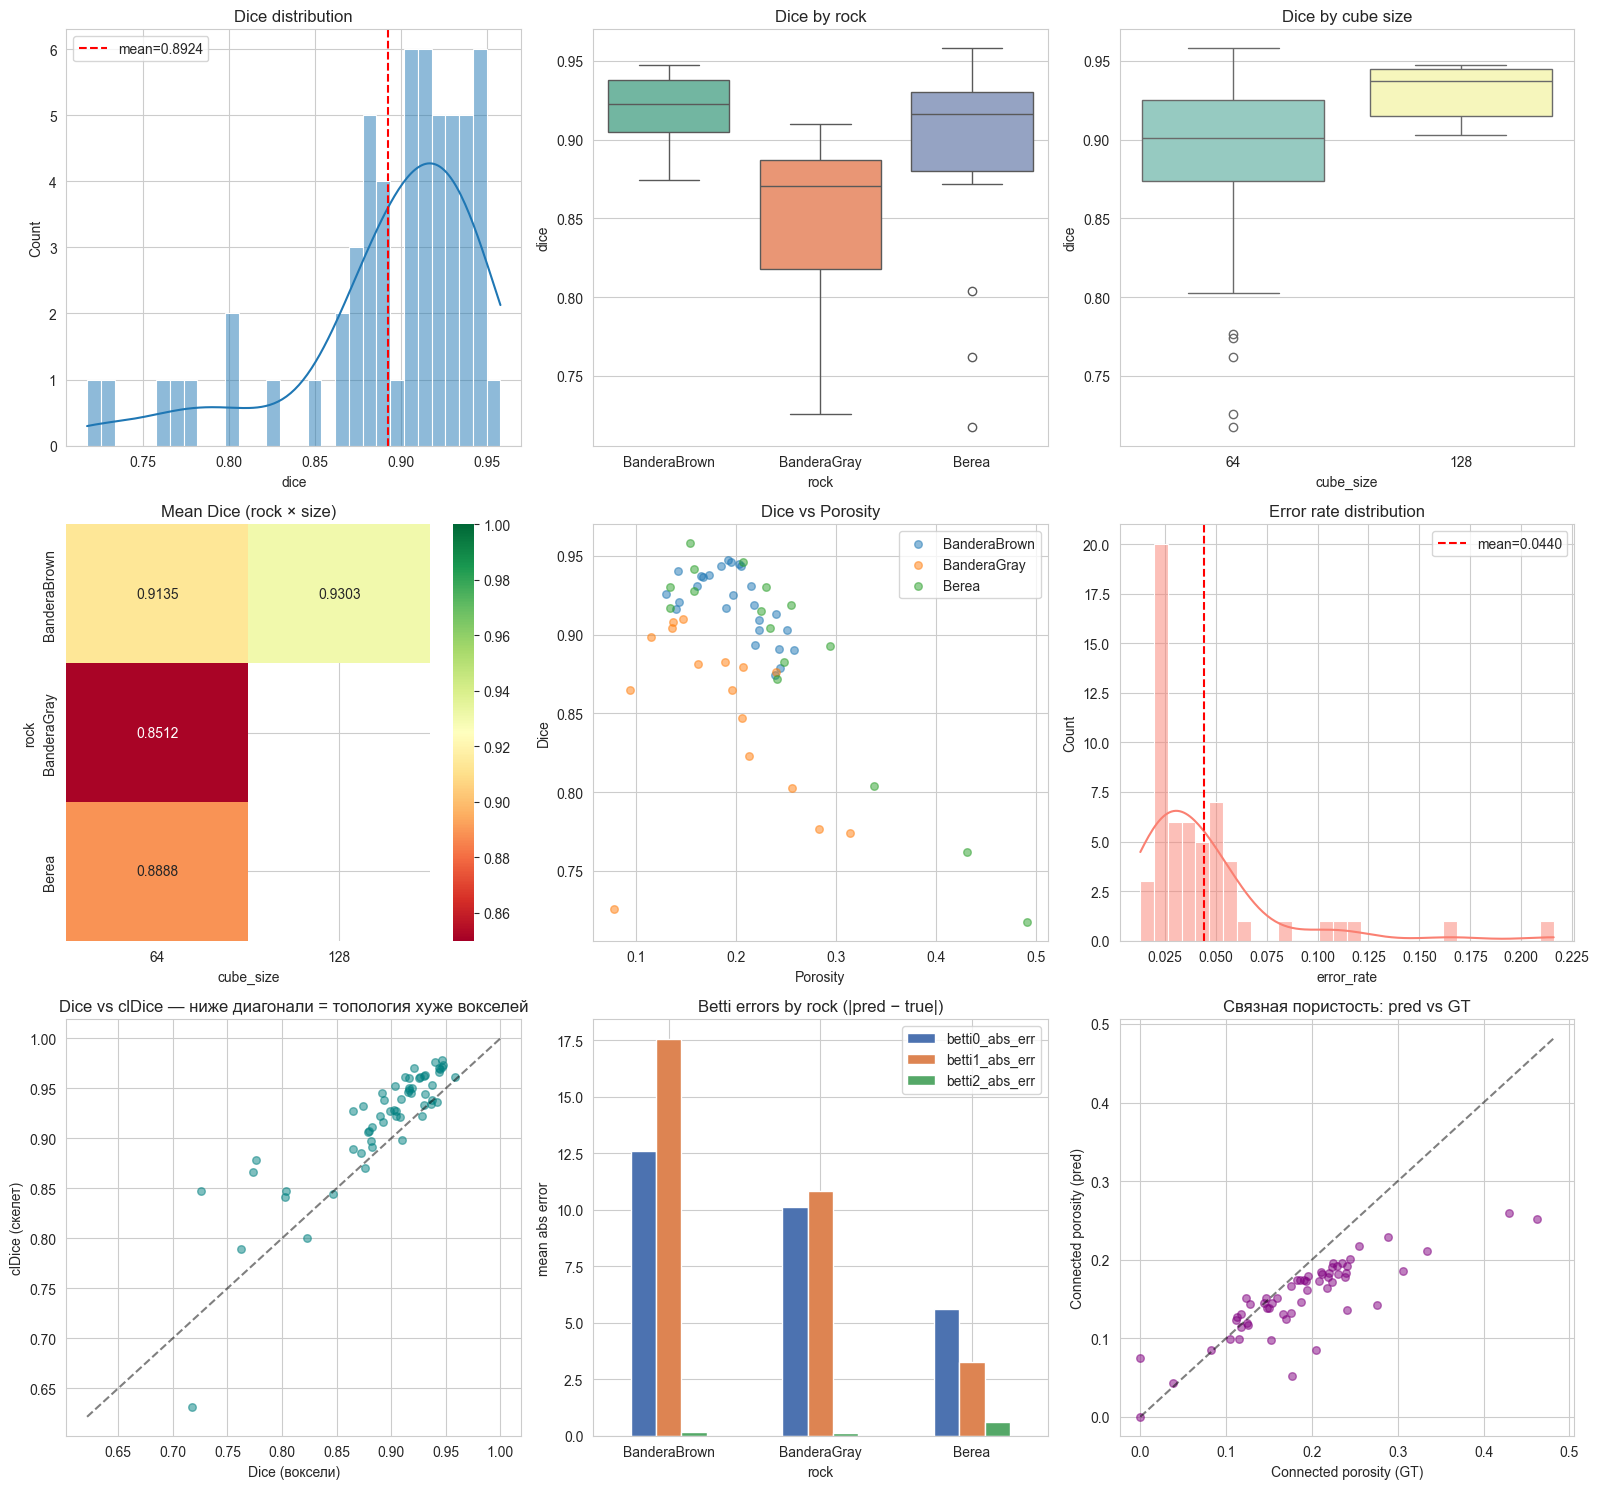

In [21]:
sns.set_style("whitegrid")
has_topo = "cl_dice" in df.columns and df["cl_dice"].notna().any()
n_rows = 3 if has_topo else 2
fig, axes = plt.subplots(n_rows, 3, figsize=(16, 5 * n_rows))

sns.histplot(df, x="dice", bins=30, ax=axes[0,0], kde=True)
axes[0,0].axvline(df["dice"].mean(), color="red", linestyle="--", label=f"mean={df['dice'].mean():.4f}")
axes[0,0].set_title("Dice distribution"); axes[0,0].legend()

sns.boxplot(data=df, x="rock", y="dice", ax=axes[0,1], palette="Set2")
axes[0,1].set_title("Dice by rock")

sns.boxplot(data=df, x="cube_size", y="dice", ax=axes[0,2], palette="Set3")
axes[0,2].set_title("Dice by cube size")

pivot = df.pivot_table(values="dice", index="rock", columns="cube_size", aggfunc="mean")
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="RdYlGn", ax=axes[1,0], vmin=0.85, vmax=1.0)
axes[1,0].set_title("Mean Dice (rock × size)")

for rock_name in df["rock"].unique():
    subset = df[df["rock"] == rock_name]
    axes[1,1].scatter(subset["porosity"], subset["dice"], alpha=0.5, label=rock_name, s=30)
axes[1,1].set_xlabel("Porosity"); axes[1,1].set_ylabel("Dice"); axes[1,1].set_title("Dice vs Porosity"); axes[1,1].legend()

sns.histplot(df, x="error_rate", bins=30, ax=axes[1,2], kde=True, color="salmon")
axes[1,2].axvline(df["error_rate"].mean(), color="red", linestyle="--", label=f"mean={df['error_rate'].mean():.4f}")
axes[1,2].set_title("Error rate distribution"); axes[1,2].legend()

if has_topo:
    topo_df = df.dropna(subset=["cl_dice"])

    # Dice vs clDice: точки сильно ниже диагонали = хороший Dice, но разрушенная связность
    axes[2,0].scatter(topo_df["dice"], topo_df["cl_dice"], alpha=0.5, s=30, c="teal")
    lims = [min(topo_df["dice"].min(), topo_df["cl_dice"].min()) - 0.01, 1.0]
    axes[2,0].plot(lims, lims, "k--", alpha=0.5)
    axes[2,0].set_xlabel("Dice (воксели)"); axes[2,0].set_ylabel("clDice (скелет)")
    axes[2,0].set_title("Dice vs clDice — ниже диагонали = топология хуже вокселей")

    betti_means = topo_df.groupby("rock")[["betti0_abs_err", "betti1_abs_err", "betti2_abs_err"]].mean()
    betti_means.plot(kind="bar", ax=axes[2,1], color=["#4c72b0", "#dd8452", "#55a868"])
    axes[2,1].set_title("Betti errors by rock (|pred − true|)")
    axes[2,1].set_ylabel("mean abs error"); axes[2,1].tick_params(axis="x", rotation=0)

    axes[2,2].scatter(topo_df["connected_porosity_true"], topo_df["connected_porosity_pred"],
                      alpha=0.5, s=30, c="purple")
    lims = [0, max(topo_df["connected_porosity_true"].max(), topo_df["connected_porosity_pred"].max()) + 0.02]
    axes[2,2].plot(lims, lims, "k--", alpha=0.5)
    axes[2,2].set_xlabel("Connected porosity (GT)"); axes[2,2].set_ylabel("Connected porosity (pred)")
    axes[2,2].set_title("Связная пористость: pred vs GT")

plt.tight_layout(); plt.show()


In [22]:
TOP_K = 10
print("WORST CUBES")
cols = ["rock", "cube_size", "dice", "error_rate", "porosity"]
if "cl_dice" in df.columns:
    cols += ["cl_dice", "betti0_abs_err", "percolation_match"]
display(df.nsmallest(TOP_K, "dice")[cols].reset_index(drop=True))
if "cl_dice" in df.columns:
    print("\nWORST BY clDICE (связность — топ-кандидаты на разорванные горла)")
    display(df.dropna(subset=["cl_dice"]).nsmallest(TOP_K, "cl_dice")[cols].reset_index(drop=True))
print("\nBEST CUBES")
display(df.nlargest(TOP_K, "dice")[cols].reset_index(drop=True))

WORST CUBES


,rock,cube_size,dice,error_rate,porosity,cl_dice,betti0_abs_err,percolation_match
0,Berea,64,0.717736,0.216030,0.490685,0.631546,4.0,1.000000
1,BanderaGray,64,0.725907,0.057762,0.077507,0.847636,11.0,0.333333
2,Berea,64,0.762061,0.165577,0.430706,0.789372,6.0,1.000000
3,BanderaGray,64,0.773791,0.115696,0.313427,0.865900,11.0,1.000000
4,BanderaGray,64,0.776601,0.103230,0.282539,0.878034,10.0,0.666667
5,BanderaGray,64,0.802564,0.084583,0.255817,0.841504,3.0,1.000000
6,Berea,64,0.803647,0.110752,0.337315,0.847277,3.0,1.000000
7,BanderaGray,64,0.823147,0.064529,0.212662,0.800185,15.0,0.333333
8,BanderaGray,64,0.846875,0.055279,0.206123,0.844216,7.0,0.666667
9,BanderaGray,64,0.864587,0.047562,0.195301,0.889272,12.0,1.000000



WORST BY clDICE (связность — топ-кандидаты на разорванные горла)


,rock,cube_size,dice,error_rate,porosity,cl_dice,betti0_abs_err,percolation_match
0,Berea,64,0.717736,0.216030,0.490685,0.631546,4.0,1.000000
1,Berea,64,0.762061,0.165577,0.430706,0.789372,6.0,1.000000
2,BanderaGray,64,0.823147,0.064529,0.212662,0.800185,15.0,0.333333
3,BanderaGray,64,0.802564,0.084583,0.255817,0.841504,3.0,1.000000
4,BanderaGray,64,0.846875,0.055279,0.206123,0.844216,7.0,0.666667
5,Berea,64,0.803647,0.110752,0.337315,0.847277,3.0,1.000000
6,BanderaGray,64,0.725907,0.057762,0.077507,0.847636,11.0,0.333333
7,BanderaGray,64,0.773791,0.115696,0.313427,0.865900,11.0,1.000000
8,BanderaGray,64,0.876010,0.053097,0.239960,0.870790,3.0,0.666667
9,BanderaGray,64,0.776601,0.103230,0.282539,0.878034,10.0,0.666667



BEST CUBES


,rock,cube_size,dice,error_rate,porosity,cl_dice,betti0_abs_err,percolation_match
0,Berea,64,0.958023,0.012909,0.153431,0.961123,6.0,1.0
1,BanderaBrown,128,0.947565,0.019774,0.192150,0.973141,28.0,1.0
2,BanderaBrown,128,0.946371,0.020258,0.194466,0.971210,24.0,1.0
3,Berea,64,0.946050,0.021431,0.206898,0.978639,7.0,1.0
4,BanderaBrown,128,0.945105,0.021373,0.202735,0.969180,11.0,1.0
5,BanderaBrown,128,0.943774,0.022127,0.204333,0.970503,21.0,1.0
6,BanderaBrown,128,0.943763,0.020174,0.184313,0.966118,39.0,1.0
7,Berea,64,0.941772,0.018089,0.157513,0.936680,3.0,1.0
8,BanderaBrown,64,0.940507,0.016994,0.141750,0.976757,2.0,1.0
9,BanderaBrown,64,0.937781,0.021183,0.172653,0.953381,1.0,1.0


In [23]:
CSV_PATH = ROOT / "outputs" / "validation_results.csv"
CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(CSV_PATH, index=False)
print(f"Saved: {CSV_PATH}")
display(df.head())

Saved: f:\PycharmProjects\micro_ct\outputs\validation_results.csv


,rock,cube_size,porosity,dice,bce_loss,error_rate,cl_dice,porosity_pred,porosity_true,porosity_abs_err,...,betti0_pred,betti0_true,betti0_abs_err,betti1_pred,betti1_true,betti1_abs_err,betti2_pred,betti2_true,betti2_abs_err,percolation_match
0,BanderaBrown,64,0.140133,0.916391,0.057240,0.024513,0.948502,0.153057,0.140133,0.012924,...,15.0,24.0,9.0,7.0,13.0,6.0,0.0,0.0,0.0,0.666667
1,BanderaBrown,64,0.242718,0.891118,0.117321,0.047737,0.945227,0.195713,0.242718,0.047005,...,9.0,7.0,2.0,4.0,12.0,8.0,0.0,0.0,0.0,1.000000
2,BanderaBrown,64,0.166298,0.936607,0.050453,0.020504,0.933944,0.157146,0.166298,0.009151,...,19.0,27.0,8.0,11.0,13.0,2.0,0.0,0.0,0.0,1.000000
3,BanderaBrown,64,0.141750,0.940507,0.041914,0.016994,0.976757,0.143906,0.141750,0.002155,...,11.0,13.0,2.0,1.0,2.0,1.0,0.0,0.0,0.0,1.000000
4,BanderaBrown,64,0.238483,0.874100,0.149457,0.053490,0.932663,0.186375,0.238483,0.052109,...,6.0,16.0,10.0,13.0,17.0,4.0,0.0,0.0,0.0,1.000000


Caching cubes for visualization...


caching:   0%|          | 0/96 [00:00<?, ?it/s]

Cached 96 cubes


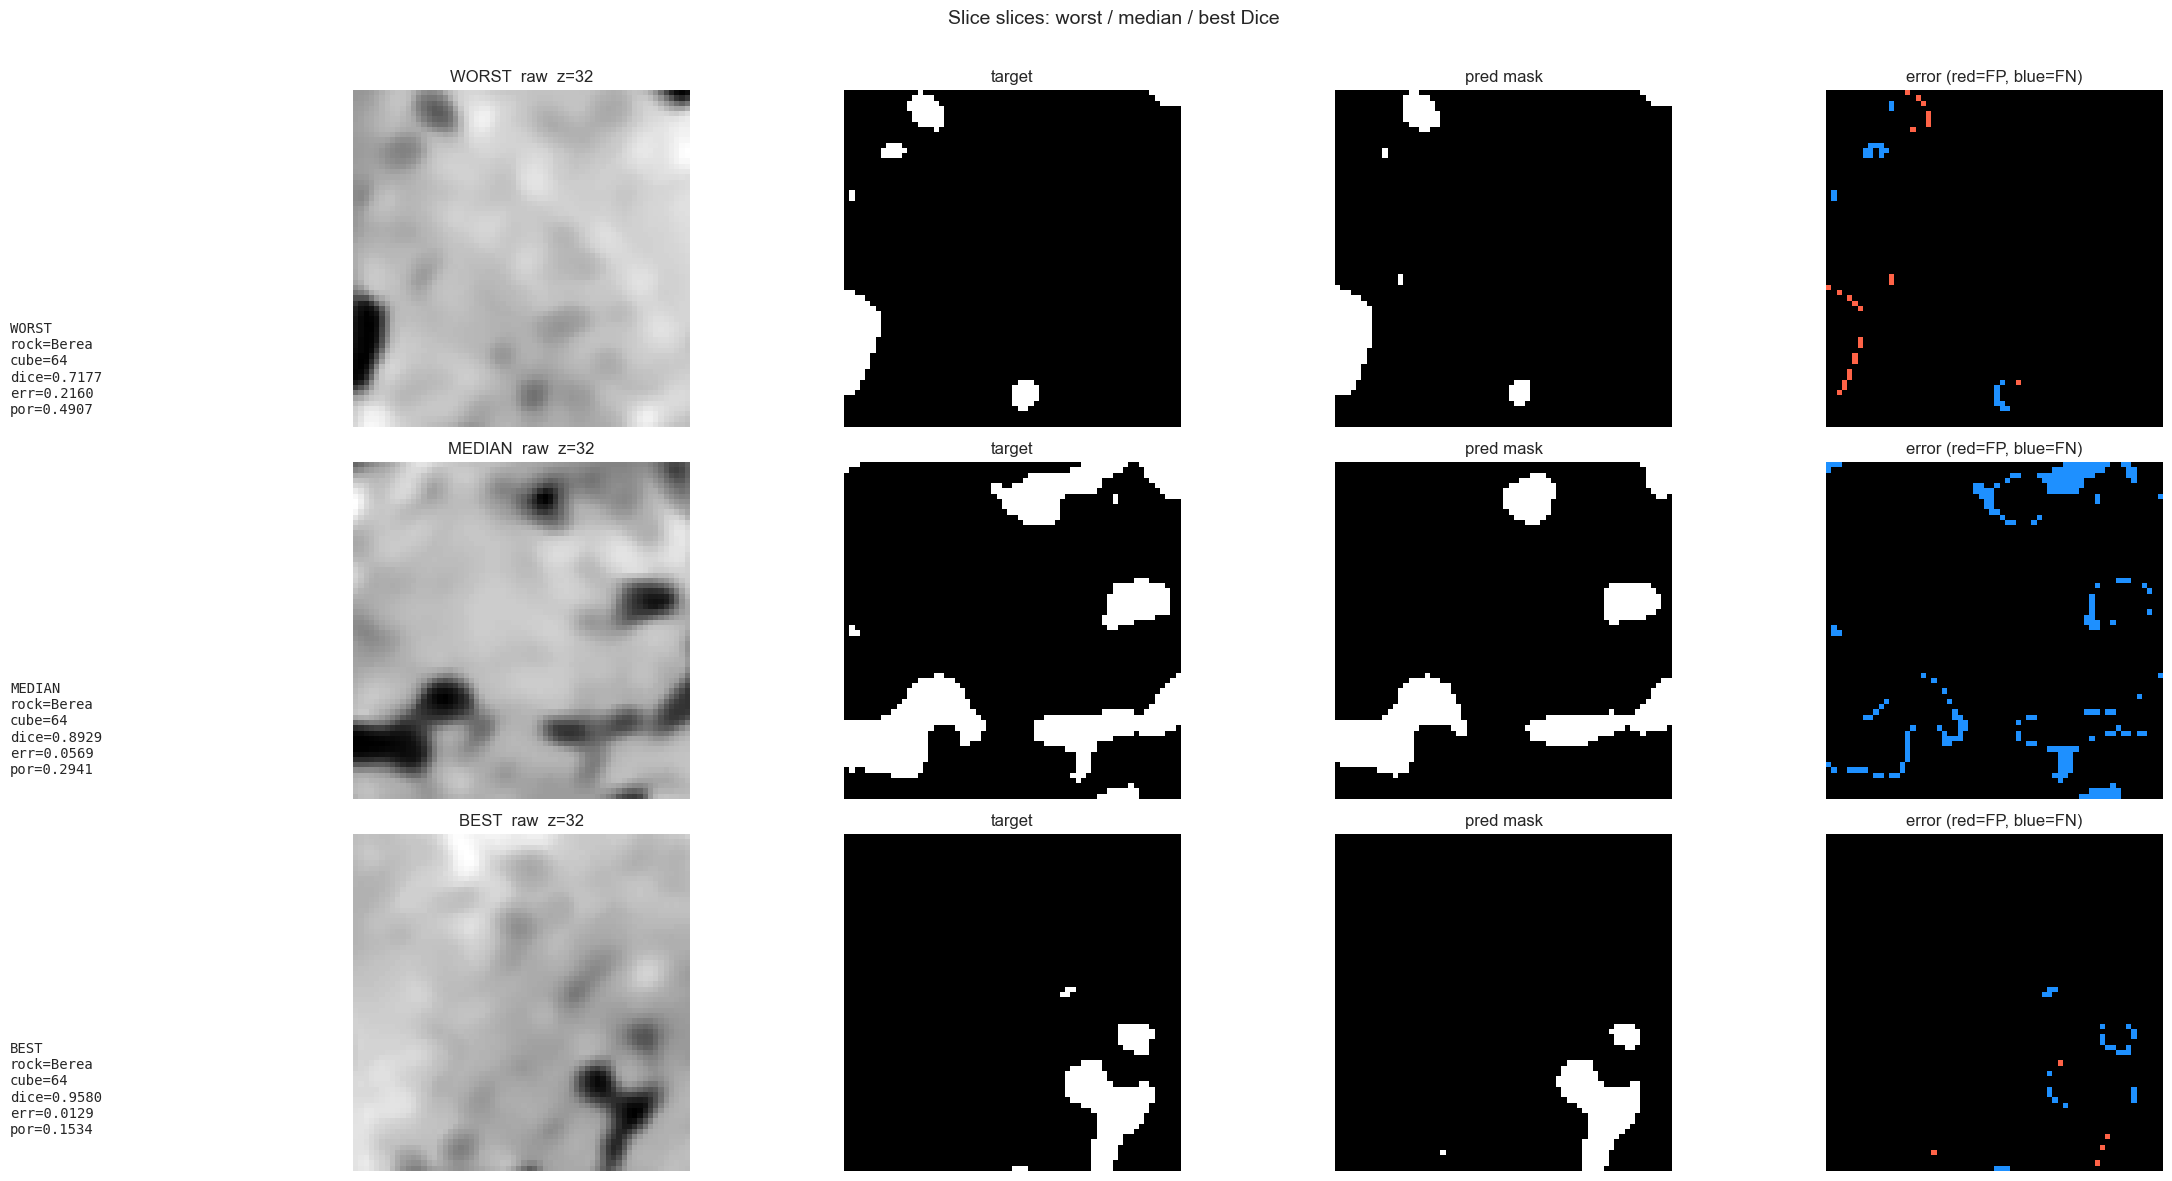

In [24]:
# ── Визуализация срезов: худший / средний / лучший по Dice ──
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
from utils import cubical_persistence_summary

# Сохраняем все x, y, pred в RAM одним проходом по val_ds
print("Caching cubes for visualization...")
all_x, all_y, all_pred = [], [], []
bce_fn = torch.nn.BCEWithLogitsLoss(reduction="none")
with torch.inference_mode():
    for i in tqdm(range(len(val_ds)), desc="caching"):
        s = val_ds[i]
        x = s["x"].unsqueeze(0).float().to(device)
        ph = s.get("ph_features")
        if ph is not None:
            ph = ph.unsqueeze(0).to(device)
        out = model(x, ph_features=ph, return_dict=True)
        prob = torch.sigmoid(out["logits"])
        all_x.append(s["x"])
        all_y.append(s["y"])
        all_pred.append((prob >= 0.5).cpu().squeeze())
print(f"Cached {len(all_x)} cubes")

worst_idx = df["dice"].idxmin()
best_idx  = df["dice"].idxmax()
median_idx = (df["dice"] - df["dice"].mean()).abs().idxmin()
picks = [("WORST", worst_idx), ("MEDIAN", median_idx), ("BEST", best_idx)]

fig, axes = plt.subplots(3, 4, figsize=(24, 12))
err_cmap = ListedColormap(["black", "tomato", "dodgerblue"])  # 0=ok, 1=FP, 2=FN

for row, (label, idx) in enumerate(picks):
    raw = all_x[idx].numpy()[0]   # (D,H,W)
    gt  = all_y[idx].numpy()[0]   # (D,H,W)
    pred = all_pred[idx].numpy()  # (D,H,W)
    cs = int(df.iloc[idx]["cube_size"])
    mid = raw.shape[0] // 2

    raw_s = raw[mid]; gt_s = gt[mid]; pred_s = pred[mid]
    err = np.zeros_like(pred_s, dtype=np.uint8)
    err[(pred_s == 1) & (gt_s == 0)] = 1  # FP
    err[(pred_s == 0) & (gt_s == 1)] = 2  # FN

    axes[row, 0].imshow(raw_s, cmap="gray");               axes[row, 0].set_title(f"{label}  raw  z={mid}"); axes[row,0].axis("off")
    axes[row, 1].imshow(gt_s, cmap="gray", vmin=0, vmax=1); axes[row, 1].set_title("target");              axes[row,1].axis("off")
    axes[row, 2].imshow(pred_s, cmap="gray", vmin=0, vmax=1); axes[row, 2].set_title("pred mask");        axes[row,2].axis("off")
    axes[row, 3].imshow(err, cmap=err_cmap, vmin=0, vmax=2); axes[row, 3].set_title("error (red=FP, blue=FN)"); axes[row,3].axis("off")

    # текстовая подпись
    r = df.iloc[idx]
    fig.text(0.04, 0.72 - row*0.30,
             f"{label}\nrock={r['rock']}\ncube={cs}\ndice={r['dice']:.4f}\nerr={r['error_rate']:.4f}\npor={r['porosity']:.4f}",
             fontsize=10, fontfamily="monospace", verticalalignment="top")

fig.suptitle("Slice slices: worst / median / best Dice", fontsize=14)
plt.tight_layout(rect=[0.12, 0, 1, 0.97])
plt.show()